# Bessel functions and cylindrical waveguides: from THz metal pipes to optical fibers

Whenever a wave lives in a round cross-section -- a metal THz waveguide, an optical fiber, a drum, a laser
cavity -- separating the Helmholtz equation $\nabla^2\psi+k^2\psi=0$ in cylindrical coordinates leaves a
radial equation that is **Bessel's equation**,
$$x^2\frac{d^2y}{dx^2}+x\frac{dy}{dx}+(x^2-n^2)\,y=0,$$
whose regular solution is the Bessel function $J_n(x)$. The physics enters through the **zeros** of $J_n$:
the boundary condition at the wall quantizes the transverse wavenumber, so the mode **cutoff frequencies
are Bessel zeros**. Two consequences we compute and verify:

- A circular **metallic THz waveguide** has cutoffs $f_c=\dfrac{c\,\chi_{nm}}{2\pi a}$ set by the zeros
  $\chi_{nm}$ of $J_n$ (TM modes) or $J_n'$ (TE modes). Shrinking the pipe pushes the cutoff *up* -- make it
  small enough and it lands in the THz band.
- An **optical fiber** is single-mode when its V-number obeys $V<2.405$ -- and $2.405$ is exactly the first
  zero of $J_0$.

We confirm $J_n$ solves Bessel's equation (SymPy), read the zeros (SciPy), compute the THz cutoffs and the
fiber single-mode limit, and check the Bessel orthogonality the mode expansion relies on. Self-contained:
NumPy, SymPy, SciPy, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
from scipy.special import jv, jvp, jn_zeros, jnp_zeros

## Bessel's equation and its solution

SymPy confirms $J_n(x)$ satisfies Bessel's equation for integer order. $J_n$ oscillates with slowly
decaying amplitude and has an infinite ladder of zeros -- the numbers that will quantize the modes.

In [3]:
x = sp.symbols('x', positive=True)
for order in (0, 1, 2):
    y = sp.besselj(order, x)
    residual = sp.simplify(x**2*sp.diff(y, x, 2) + x*sp.diff(y, x) + (x**2 - order**2)*y)
    assert residual == 0
    print(f"J_{order} satisfies Bessel's equation (residual {residual})")
print("\nfirst zeros of J_0:", np.round(jn_zeros(0, 4), 4), " (2.4048 = fiber single-mode limit)")
print("first zeros of J_1':", np.round(jnp_zeros(1, 3), 4), " (1.8412 = dominant TE11 waveguide mode)")

J_0 satisfies Bessel's equation (residual 0)
J_1 satisfies Bessel's equation (residual 0)
J_2 satisfies Bessel's equation (residual 0)

first zeros of J_0: [ 2.4048  5.5201  8.6537 11.7915]  (2.4048 = fiber single-mode limit)
first zeros of J_1': [1.8412 5.3314 8.5363]  (1.8412 = dominant TE11 waveguide mode)


## Circular metallic waveguide: THz cutoffs from Bessel zeros

In a hollow metal pipe of radius $a$ a mode propagates only above its cutoff $f_c=c\,\chi/(2\pi a)$, where
$\chi=\chi_{nm}$ (zero of $J_n$) for **TM** modes and $\chi=\chi'_{nm}$ (zero of $J_n'$) for **TE** modes.
The dominant mode is $\mathrm{TE}_{11}$ ($\chi'_{11}=1.8412$). Because $f_c\propto1/a$, shrinking the guide
raises every cutoff -- a sub-millimetre bore puts the fundamental into the **terahertz** band.

In [4]:
c = 2.99792458e8
def cutoff_hz(chi, a_m):
    return c*chi/(2*np.pi*a_m)

modes = {"TE11": jnp_zeros(1, 1)[0], "TM01": jn_zeros(0, 1)[0],
         "TE21": jnp_zeros(2, 1)[0], "TM11": jn_zeros(1, 1)[0]}
rows = []
for a_mm in (0.5, 0.2, 0.1):
    row = {"radius [mm]": a_mm}
    for name, chi in modes.items():
        row[f"{name} [THz]"] = round(cutoff_hz(chi, a_mm*1e-3)/1e12, 3)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))
assert cutoff_hz(modes["TE11"], 0.1e-3) > 0.5e12                     # 0.1 mm bore -> TE11 above 0.5 THz
print(f"\nTE11 cutoff scales as 1/a: 0.5mm -> {cutoff_hz(modes['TE11'],0.5e-3)/1e12:.3f} THz, "
      f"0.1mm -> {cutoff_hz(modes['TE11'],0.1e-3)/1e12:.3f} THz  (smaller bore, higher cutoff)")

 radius [mm]  TE11 [THz]  TM01 [THz]  TE21 [THz]  TM11 [THz]
         0.5       0.176       0.229       0.291       0.366
         0.2       0.439       0.574       0.729       0.914
         0.1       0.878       1.147       1.457       1.828

TE11 cutoff scales as 1/a: 0.5mm -> 0.176 THz, 0.1mm -> 0.878 THz  (smaller bore, higher cutoff)


## Optical fiber: the single-mode limit is the first zero of $J_0$

A step-index fiber's normalized frequency is $V=\dfrac{2\pi a}{\lambda}\,\mathrm{NA}$. The fundamental
$\mathrm{LP}_{01}$ mode always propagates; the next mode $\mathrm{LP}_{11}$ turns on at $V=2.405=\chi_{01}$,
the first zero of $J_0$. So a fiber is **single-mode** precisely when $V<2.405$ -- Bessel zeros again, now
setting the core radius for single-mode operation.

In [5]:
V_cutoff = jn_zeros(0, 1)[0]
lam, NA = 1.55e-6, 0.14                                              # telecom wavelength, typical NA
a_singlemode = V_cutoff*lam/(2*np.pi*NA)
print(f"single-mode cutoff V = {V_cutoff:.4f}  (= first zero of J_0)")
print(f"max core radius for single-mode at {lam*1e6:.2f} um, NA={NA}: a < {a_singlemode*1e6:.2f} um")
# a fiber with a = 4 um: is it single-mode?
V_example = 2*np.pi*4e-6/lam*NA
print(f"a=4.0 um -> V = {V_example:.3f} -> {'single-mode' if V_example < V_cutoff else 'multi-mode'}")
assert V_example < V_cutoff

single-mode cutoff V = 2.4048  (= first zero of J_0)
max core radius for single-mode at 1.55 um, NA=0.14: a < 4.24 um
a=4.0 um -> V = 2.270 -> single-mode


## Bessel orthogonality (the basis for mode expansion)

Fields in a circular guide expand in $J_n(\chi_{nm}r/a)$; this works because these are orthogonal on
$[0,a]$ with weight $r$: $\int_0^a r\,J_n(\chi_{nm}r/a)\,J_n(\chi_{nk}r/a)\,dr=0$ for $m\neq k$ and
$\tfrac{a^2}{2}J_{n+1}(\chi_{nm})^2$ for $m=k$. We verify both numerically.

In [6]:
a = 1.0; ncyl = 1
chi = jn_zeros(ncyl, 4)
rr = np.linspace(0, a, 20000)
def overlap(m, k):
    return np.trapezoid(rr*jv(ncyl, chi[m]*rr/a)*jv(ncyl, chi[k]*rr/a), rr)
print("off-diagonal <m=0,k=1> =", f"{overlap(0,1):.2e}", " (~0, orthogonal)")
print("diagonal   <m=0,k=0> =", f"{overlap(0,0):.5f}", " vs a^2/2 J_{n+1}(chi)^2 =",
      f"{a**2/2*jv(ncyl+1, chi[0])**2:.5f}")
assert abs(overlap(0,1)) < 1e-4
assert abs(overlap(0,0) - a**2/2*jv(ncyl+1, chi[0])**2) < 1e-4

off-diagonal <m=0,k=1> = 0.00e+00  (~0, orthogonal)
diagonal   <m=0,k=0> = 0.08111  vs a^2/2 J_{n+1}(chi)^2 = 0.08111


## Plots

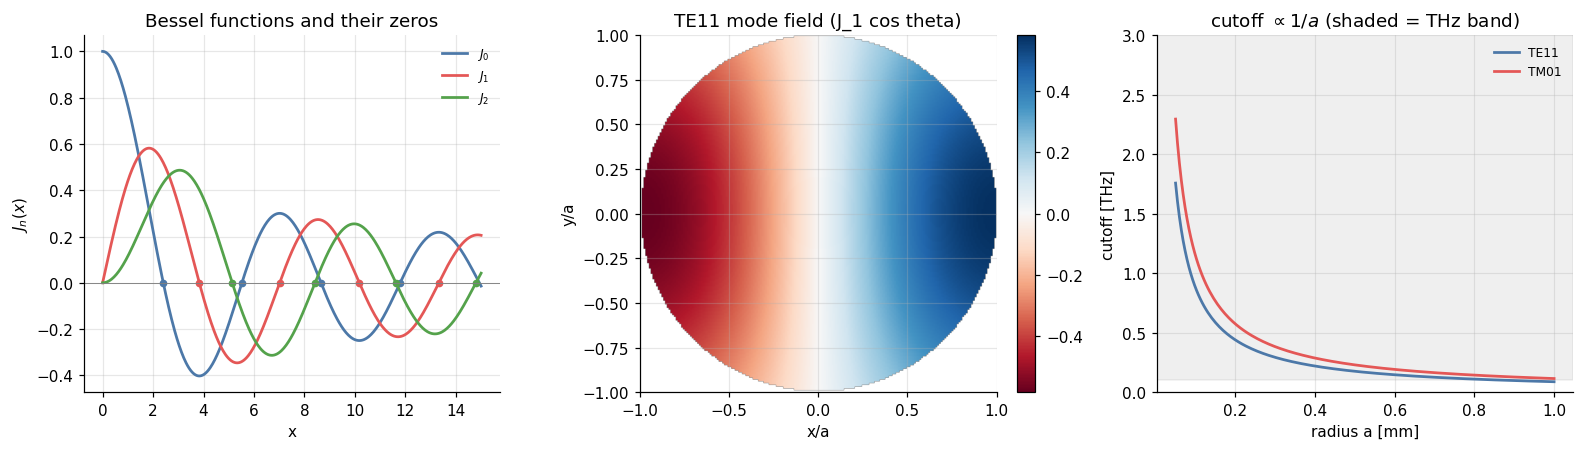

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
xs = np.linspace(0, 15, 500)
for order, col in zip((0, 1, 2), ("#4C78A8", "#E45756", "#54A24B")):
    ax[0].plot(xs, jv(order, xs), color=col, label=f"$J_{order}$")
    ax[0].plot(jn_zeros(order, 4), np.zeros(4), "o", color=col, ms=4)
ax[0].axhline(0, color="gray", lw=0.6); ax[0].set_xlabel("x"); ax[0].set_ylabel("$J_n(x)$")
ax[0].set_title("Bessel functions and their zeros"); ax[0].legend(fontsize=8)
# TE11 transverse field pattern J_1(chi' r/a) cos(theta) on the disk
N = 200; g = np.linspace(-1, 1, N); X, Y = np.meshgrid(g, g)
R = np.sqrt(X**2 + Y**2); TH = np.arctan2(Y, X)
field = np.where(R <= 1, jv(1, jnp_zeros(1, 1)[0]*R)*np.cos(TH), np.nan)
im = ax[1].imshow(field, extent=[-1, 1, -1, 1], cmap="RdBu"); ax[1].set_title("TE11 mode field (J_1 cos theta)")
ax[1].set_xlabel("x/a"); ax[1].set_ylabel("y/a"); fig.colorbar(im, ax=ax[1], fraction=0.046)
# cutoff vs radius (1/a), THz band shaded
a_mm = np.linspace(0.05, 1.0, 200)
ax[2].plot(a_mm, cutoff_hz(modes["TE11"], a_mm*1e-3)/1e12, color="#4C78A8", label="TE11")
ax[2].plot(a_mm, cutoff_hz(modes["TM01"], a_mm*1e-3)/1e12, color="#E45756", label="TM01")
ax[2].axhspan(0.1, 10, color="gray", alpha=0.12); ax[2].set_ylim(0, 3)
ax[2].set_xlabel("radius a [mm]"); ax[2].set_ylabel("cutoff [THz]")
ax[2].set_title("cutoff $\\propto 1/a$ (shaded = THz band)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

- Cylindrical symmetry turns the Helmholtz equation into **Bessel's equation**; $J_n$ is the regular
  solution (SymPy-verified), and its **zeros** quantize every round-waveguide mode.
- A **metallic THz waveguide** has cutoffs $f_c=c\chi_{nm}/(2\pi a)$ from the zeros of $J_n$ (TM) / $J_n'$
  (TE); the dominant $\mathrm{TE}_{11}$ uses $\chi'_{11}=1.8412$, and $f_c\propto1/a$ pushes a sub-mm bore
  into the terahertz band.
- An **optical fiber** is single-mode for $V<2.405$ -- the first zero of $J_0$ -- which fixes the core
  radius (< ~4.2 um at 1.55 um, NA 0.14).
- Bessel functions are **orthogonal** with weight $r$, the basis that makes cylindrical mode expansion work
  (verified).

Subject-verb-object: cylindrical symmetry breeds Bessel's equation; its zeros set the cutoffs; a smaller
bore raises them into the THz; the same zero makes a fiber single-mode.